Task-1: Data Cleaning and Preprocessing

In [1]:
import pandas as pd

1. Load the dataset

In [2]:
df = pd.read_csv('Stock Prices Data Set.csv')

# Print the Top data
df.head()

,symbol,date,open,high,low,close,volume
0,AAL,2014-01-02,25.0700,25.8200,25.0600,25.3600,8998943
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957
2,AAP,2014-01-02,110.3600,111.8800,109.2900,109.7400,542711
3,ABBV,2014-01-02,52.1200,52.3300,51.5200,51.9800,4569061
4,ABC,2014-01-02,70.1100,70.2300,69.4800,69.8900,1148391


2. Initial Data Inspection

In [3]:
df.info()

# Count missing values per column
print("\nMissing values:")
print(df.isnull().sum())

# Count duplicate rows
print(f"\nDuplicate rows found: {df.duplicated().sum()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 497472 entries, 0 to 497471
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   symbol  497472 non-null  object 
 1   date    497472 non-null  object 
 2   open    497461 non-null  float64
 3   high    497464 non-null  float64
 4   low     497464 non-null  float64
 5   close   497472 non-null  float64
 6   volume  497472 non-null  int64  
dtypes: float64(4), int64(1), object(2)
memory usage: 26.6+ MB

Missing values:
symbol     0
date       0
open      11
high       8
low        8
close      0
volume     0
dtype: int64

Duplicate rows found: 0


3. Handle Missing Values

In [4]:
# Drop rows with any missing values
df = df.dropna()

# Verify no missing values remain
print(f"Rows remaining after dropping nulls: {len(df)}")

Rows remaining after dropping nulls: 497461


4. Standardize Inconsistent Formats

In [5]:
# Standardize 'date' format to pandas datetime objects
df['date'] = pd.to_datetime(df['date'])

# Standardize 'symbol' (strip spaces and convert to uppercase)
df['symbol'] = df['symbol'].str.strip().str.upper()

# Check standardized symbols and date format
print(f"Date data type: {df['date'].dtype}")
print("Unique symbols (sample):", df['symbol'].unique()[:10])

Date data type: datetime64[ns]
Unique symbols (sample): ['AAL' 'AAPL' 'AAP' 'ABBV' 'ABC' 'ABT' 'ACN' 'ADBE' 'ADI' 'ADM']


5. Save to a new CSV file

In [6]:
df.to_csv('cleaned_stock_prices.csv', index=False)
print("Data cleaning complete. Cleaned file saved as 'cleaned_stock_prices.csv'")

Data cleaning complete. Cleaned file saved as 'cleaned_stock_prices.csv'


Task-3: Basic Data Visualization

1. Importing Librabries

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

2. Load the Dataset

In [8]:
# Set the visualization style
sns.set_theme(style="whitegrid")

# Load the stock prices dataset
df = pd.read_csv('Stock Prices Data Set.csv')

# Preprocessing: Convert date column to datetime objects
df['date'] = pd.to_datetime(df['date'])

# Preview the data
df.head()

,symbol,date,open,high,low,close,volume
0,AAL,2014-01-02,25.0700,25.8200,25.0600,25.3600,8998943
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957
2,AAP,2014-01-02,110.3600,111.8800,109.2900,109.7400,542711
3,ABBV,2014-01-02,52.1200,52.3300,51.5200,51.9800,4569061
4,ABC,2014-01-02,70.1100,70.2300,69.4800,69.8900,1148391


3. Create a Bar Plot (Categorical Comparison)

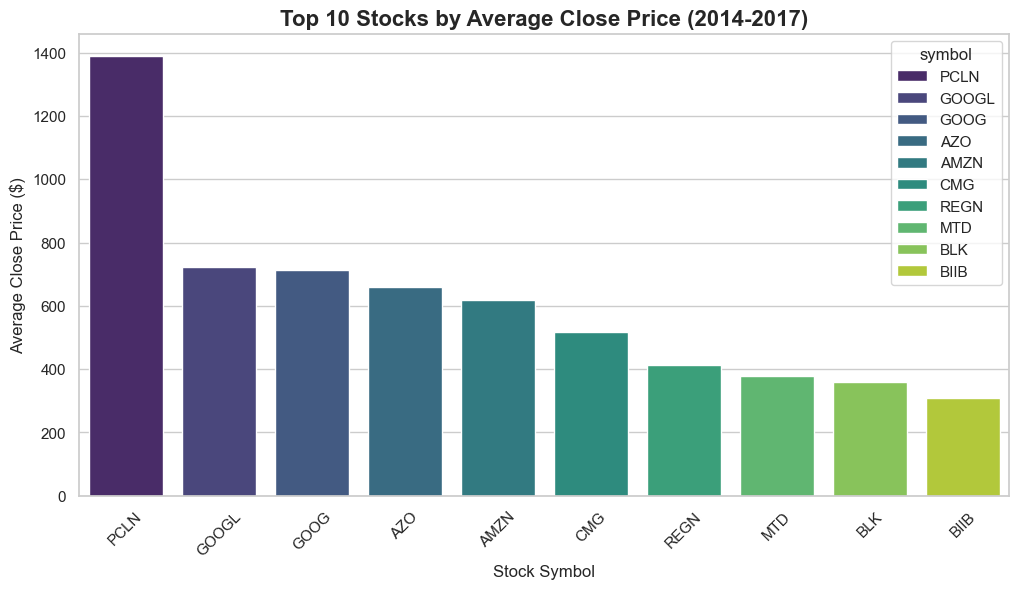

In [9]:
# Aggregate data: Calculate average close price for each symbol
avg_close = df.groupby('symbol')['close'].mean().reset_index().sort_values(by='close', ascending=False).head(10)

# Create the bar plot
plt.figure(figsize=(12, 6))
sns.barplot(data=avg_close, x='symbol', y='close', palette='viridis', hue='symbol', dodge=False)

# Customization
plt.title('Top 10 Stocks by Average Close Price (2014-2017)', fontsize=16, fontweight='bold')
plt.xlabel('Stock Symbol', fontsize=12)
plt.ylabel('Average Close Price ($)', fontsize=12)
plt.xticks(rotation=45) # Rotate labels for better readability

# Export plot
plt.savefig('top_stocks_bar.png', dpi=300, bbox_inches='tight')
plt.show()

4. Create a Line Chart (Trend Analysis)

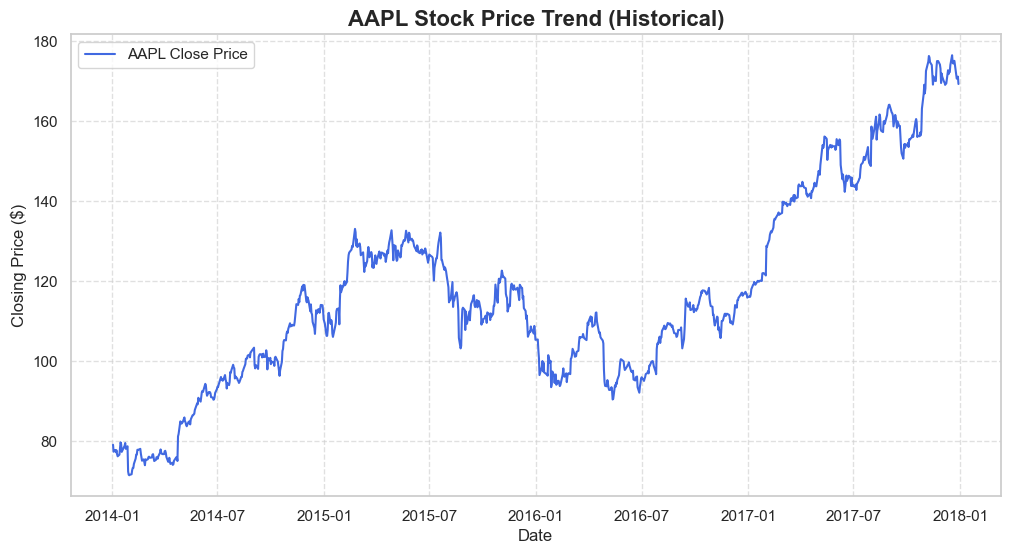

In [10]:
# Filter data for a specific stock
aapl_df = df[df['symbol'] == 'AAPL'].sort_values(by='date')

# Create the line chart
plt.figure(figsize=(12, 6))
sns.lineplot(data=aapl_df, x='date', y='close', color='royalblue', linewidth=1.5, label='AAPL Close Price')

# Customization
plt.title('AAPL Stock Price Trend (Historical)', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Closing Price ($)', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)

# Export plot
plt.savefig('aapl_trend_line.png', dpi=300, bbox_inches='tight')
plt.show()

5. Create a Scatter Plot (Correlation)

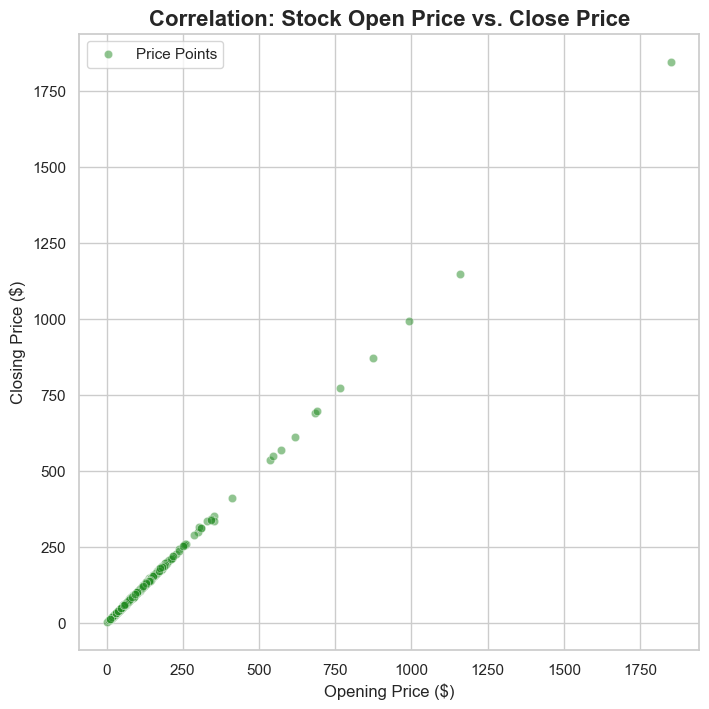

In [11]:
# Since the dataset is huge, we'll take a random sample of 1000 points to avoid clutter
sample_df = df.sample(1000, random_state=42)

# Create the scatter plot
plt.figure(figsize=(8, 8))
sns.scatterplot(data=sample_df, x='open', y='close', alpha=0.5, color='forestgreen', label='Price Points')

# Customization
plt.title('Correlation: Stock Open Price vs. Close Price', fontsize=16, fontweight='bold')
plt.xlabel('Opening Price ($)', fontsize=12)
plt.ylabel('Closing Price ($)', fontsize=12)
plt.legend()

# Export plot
plt.savefig('open_close_scatter.png', dpi=300, bbox_inches='tight')
plt.show()